### 🧠 **04. Introduction aux Réseaux de Neurones**

Bienvenue dans le **Deep Learning** ! Nous allons construire un cerveau artificiel très simple pour reconnaître des chiffres écrits à la main.

---

#### **Objectif**
Classer des images de chiffres (0 à 9) provenant du dataset MNIST.

#### 📌 **Plan du notebook**
- 📥 Chargement de TensorFlow/Keras
- 🖼️ Visualisation des images MNIST
- 🏗️ Construction d'un réseau de neurones simple (Perceptron Multicouche)
- ⚙️ Compilation et Entraînement
- 📊 Évaluation de la précision

### 📥 **Chargement des librairies**

In [16]:
import tensorflow as tf   # pip install tensorflow
from tensorflow.keras import layers, models   
import matplotlib.pyplot as plt
import numpy as np

print(f"✅ TensorFlow version: {tf.__version__}")

✅ TensorFlow version: 2.21.0


### 🖼️ **Chargement et Visualisation de MNIST**

🔗 Lien Kaggle : [Digit Recognizer](https://www.kaggle.com/c/digit-recognizer)

Le dataset contient 60 000 images de 28x28 pixels.

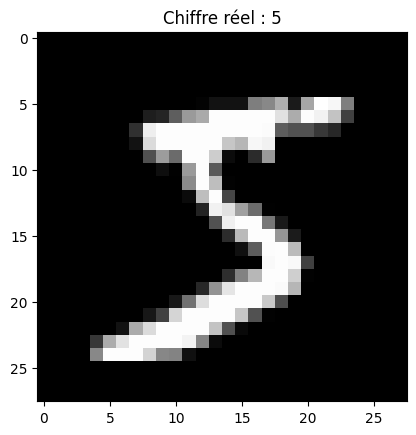

In [9]:
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalisation (mettre les pixels entre 0 et 1)
X_train, X_test = X_train / 255.0, X_test / 255.0

# Affichage d'un exemple
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Chiffre réel : {y_train[0]}")
plt.show()

### 🏗️ **Construction du modèle**

Nous créons un modèle **Séquentiel** :
1. `Flatten` : Transforme l'image 28x28 en un vecteur plat de 784 pixels.
2. `Dense` (128 neurones) : Couche cachée avec activation **ReLU**.
3. `Dropout` : Technique pour éviter l'overfitting.
4. `Dense` (10 neurones) : Couche de sortie (un neurone par chiffre).

In [13]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### ⚙️ **Entraînement**

In [11]:
print("🚀 Début de l'entraînement...")
history = model.fit(X_train, y_train, epochs=5, validation_split=0.1)


🚀 Début de l'entraînement...
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9113 - loss: 0.3051 - val_accuracy: 0.9647 - val_loss: 0.1286
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9549 - loss: 0.1505 - val_accuracy: 0.9730 - val_loss: 0.0973
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9663 - loss: 0.1129 - val_accuracy: 0.9742 - val_loss: 0.0846
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9722 - loss: 0.0929 - val_accuracy: 0.9757 - val_loss: 0.0785
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9753 - loss: 0.0794 - val_accuracy: 0.9775 - val_loss: 0.0762


### 📊 **Évaluation**

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n✅ Précision sur le jeu de test : {test_acc:.4f}")

313/313 - 2s - 6ms/step - accuracy: 0.9747 - loss: 0.0820

✅ Précision sur le jeu de test : 0.9747


### ✅ **Concepts clés**

- **Activation (ReLU)** : Permet au réseau d'apprendre des relations complexes.
- **Rétropropagation** : La méthode par laquelle le réseau ajuste ses poids pour réduire l'erreur.
- **Époques** : Le nombre de fois que le modèle voit tout le dataset.